In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [2]:
# NSL-KDD columns
with open("feature_names.txt") as f:
    cols = [line.strip() for line in f]

# Load data
train = pd.read_csv("KDDTrain+.txt", names=cols)
test = pd.read_csv("KDDTest+.txt", names=cols)

# Verify dataset dimensions
assert train.shape[1] == 43
assert test.shape[1] == 43

print("Training set shape:", train.shape)
print("Test set shape:", test.shape)


Training set shape: (125973, 43)
Test set shape: (22544, 43)


In [3]:
def load_data():

    with open("feature_names.txt") as f:
        cols = [line.strip() for line in f]

    train = pd.read_csv("KDDTrain+.txt", names=cols)
    test = pd.read_csv("KDDTest+.txt", names=cols)

    train['label'] = train['label'].apply(
        lambda x: 0 if str(x).strip().startswith("normal") else 1
    )

    test['label'] = test['label'].apply(
        lambda x: 0 if str(x).strip().startswith("normal") else 1
    )

    for col in ['protocol_type','service','flag']:

        le = LabelEncoder()

        allvals = pd.concat([train[col], test[col]])

        le.fit(allvals)

        train[col] = le.transform(train[col])
        test[col] = le.transform(test[col])

    return train, test

train, test = load_data()

In [4]:
def prepare_data(train, test):

    X_train = train.drop('label', axis=1)
    y_train = train['label']

    X_test = test.drop('label', axis=1)
    y_test = test['label']

    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = prepare_data(train,test)

In [6]:
def train_random_forest(X_train,y_train):

    model_rf = RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=42
    )

    model_rf.fit(X_train,y_train)

    return model_rf

model_rf = train_random_forest(X_train,y_train)

pred_rf = model_rf.predict(X_test)

In [13]:
def train_logistic_regression(X_train,
                              X_test,
                              y_train):

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    model_lr = LogisticRegression(
        class_weight='balanced',
        max_iter=5000,
        random_state=42
    )

    model_lr.fit(X_train_scaled,y_train)

    return model_lr, scaler, X_test_scaled

model_lr, scaler, X_test_scaled = train_logistic_regression(
    X_train,
    X_test,
    y_train
)

pred_lr = model_lr.predict(X_test_scaled)

In [11]:
def evaluate_model(model_name,
                   y_true,
                   y_pred):

    print("\n===== ",model_name," =====")

    print(classification_report(y_true,y_pred))

    cm = confusion_matrix(y_true,y_pred)

    print(cm)

    return cm

In [14]:
cm_rf = evaluate_model(
    "Random Forest",
    y_test,
    pred_rf
)

cm_lr = evaluate_model(
    "Logistic Regression",
    y_test,
    pred_lr
)


=====  Random Forest  =====
              precision    recall  f1-score   support

           0       0.72      0.97      0.83      9711
           1       0.97      0.71      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.84      0.84      0.82     22544
weighted avg       0.86      0.82      0.82     22544

[[9447  264]
 [3728 9105]]

=====  Logistic Regression  =====
              precision    recall  f1-score   support

           0       0.77      0.92      0.84      9711
           1       0.93      0.79      0.85     12833

    accuracy                           0.84     22544
   macro avg       0.85      0.85      0.84     22544
weighted avg       0.86      0.84      0.85     22544

[[ 8963   748]
 [ 2753 10080]]


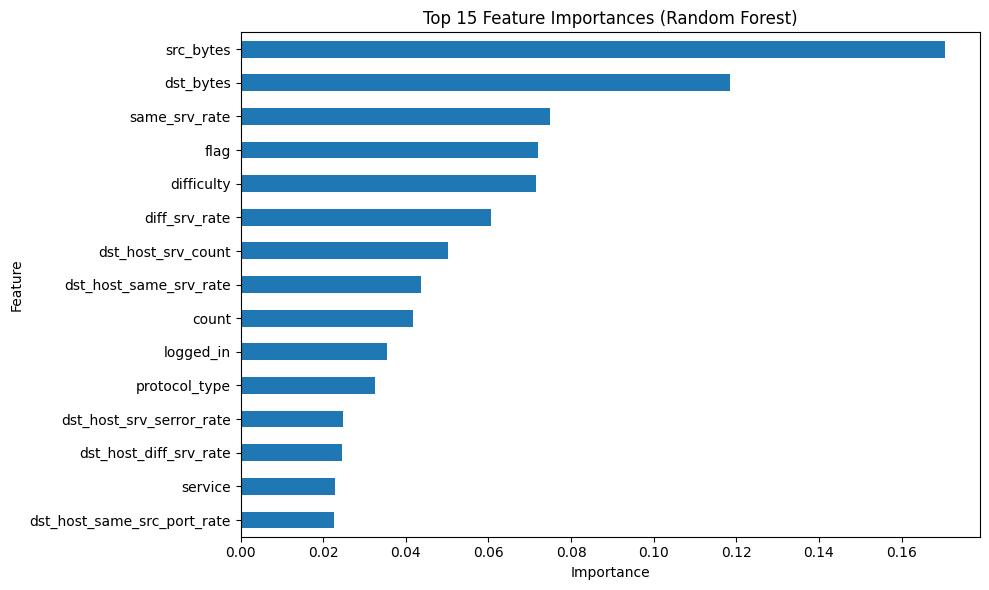

In [15]:
# Feature importance from Random Forest

feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
)

# Top 15 features
top_features = feature_importance.sort_values(
    ascending=False
).head(15)

plt.figure(figsize=(10,6))

top_features.plot(
    kind='barh'
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances (Random Forest)")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [18]:
def plot_confusion_matrix(cm, title):

    plt.figure(figsize=(5,5))

    plt.imshow(cm,
               interpolation='nearest')

    plt.title(title)

    plt.colorbar()

    plt.xticks([0,1], ['Normal','Attack'])
    plt.yticks([0,1], ['Normal','Attack'])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i,j],
                ha='center',
                va='center',
                color='black'
            )

    plt.tight_layout()
    plt.show()

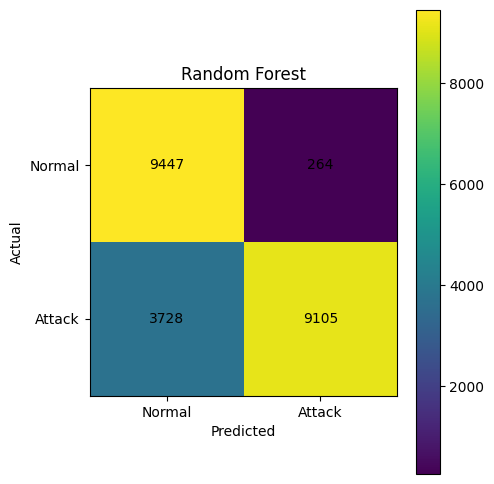

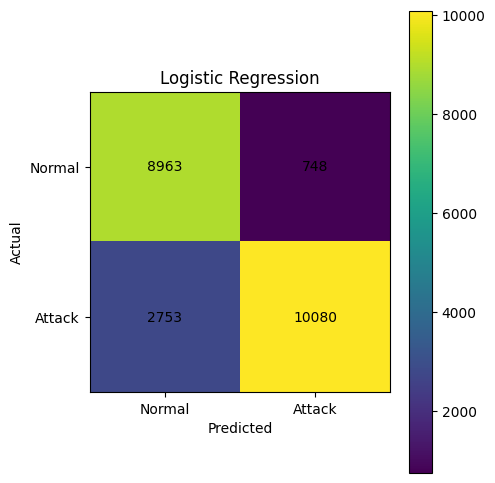

In [19]:
plot_confusion_matrix(cm_rf,
                      "Random Forest")

plot_confusion_matrix(cm_lr,
                      "Logistic Regression")